# sotodlib Tutorial

Author : Henry Nachman

Date : 11 September 2026

---

The software package sotodlib includes a number of processes for mapmaking of both real and simulated time-ordered data. 

This notebook is adapted from the Maximum Likelihood Mapmaking tutorial at the F2F 2026

# Imports

In [1]:
import os
os.environ["TOAST_LOGLEVEL"] = "INFO"
# This is needed before importing toast, and should
# match the value passed to the '-t' option of %toast
os.environ["OMP_NUM_THREADS"] = "4"

In [2]:
# TOAST interactive startup
import toast.interactive
%load_ext toast.interactive
%toast -p 1 -t 4 -a

TOAST INFO: Using 1 processes with 4 threads each.


In [3]:
# General Imports
import os
import re
import glob
import argparse

import numpy as np
import astropy.io.fits as af
from astropy import units as u
import matplotlib.pyplot as plt

# Import sotodlib.toast first, since that sets default object names
# to use in toast.
import sotodlib.toast as sotoast

import toast
from toast.observation import default_values as defaults

import sotodlib
import sotodlib.toast.ops as so_ops

abspath = os.path.dirname(os.path.abspath("sim_ml_mapmaking.ipynb"))

In [4]:
# MPI communicator
world, procs, rank = toast.mpi.get_world()

# Configuration

Generally, if we want to run the same processing and operators on data we don't want to have to retype all of that code, so we save the process information in configuration files.

In [5]:
# Config file location
config_dir = f"{abspath}/configs"
config_lat_dir = os.path.join(config_dir, "lat")

if not os.path.exists(config_lat_dir):
    raise FileNotFoundError(f"{config_lat_dir}")
# Optional site-pipeline preprocessing config.  These are specialized
# operations that do not yet have equivalents in toast.  These operations
# will be applied when the data is loaded.
site_preproc = os.path.join(config_lat_dir, "site_proc.yml")

# Area file.  This defines the projection for the ML mapmaker.
area_file = "so_geometry_v20241015_2p0.fits"

# Data Selection

In this notebook we will use data from a LAT observation. Here we define what data to pull and from where.

In [6]:
# The observation(s) we are using
tele_name = "lat"

# Standard context
# Context File for NERSC
context_file = f"/global/cfs/cdirs/sobs/metadata/{tele_name}/contexts/use_this_local.yaml"
# Context File for SO-UK
context_file = f"/cephfs/soukdata/data/tracked/metadata/{tele_name}/contexts/use_this_local.yaml"
if not os.path.exists(context_file):
    raise FileNotFoundError("The context file was not found, please make sure you have specified the correct file for this local machine.")

# Observation for this exercise
obs_id = "obs_1761519423_lati1_111"

# Select one wafer / frequency
det_select = {"wafer.bandpass":"f090","stream_id":"ufm_mv21"}


In [7]:
# Output directory.
out_dir = "."
if rank == 0:
    os.makedirs(out_dir, exist_ok=True)
if world is not None:
    out_dir = world.bcast(out_dir, root=0)

# Helper Functions

There are a couple of useful helper functions and plotting functions. For convenience I have put these in a seperate file which we will import here.

In [8]:
from helper import *

# Load Config Files

Instead of manually running each operator and specifying individual options, we use the same config files that we will use in the corresponding batch jobs.  We use some of the "nominal" configs for many steps and also load a local mapmaking config file.

In [9]:
parser = argparse.ArgumentParser()
opts = [
    "--config",
    os.path.join(config_dir, "load_context.yml"), # General data loading
    os.path.join(config_dir, "pointing_detector.yml"), # Detector quaternion pointing
    os.path.join(config_dir, "pre_proc.yml"), # Low-level preprocessing
    os.path.join(config_lat_dir, "pointing.yml"),
    os.path.join(config_dir, "sim_pointing_detector.yml"),
    os.path.join(config_lat_dir, "sim_pointing.yml"),
    os.path.join(config_dir, "sim_sky_alm.yml"),
    os.path.join(config_dir, "sim_noise.yml"),
    os.path.join(config_dir, "sim_atmosphere.yml"),
    os.path.join(config_dir, "simulation.yml"),
    os.path.join(config_dir, "mapmaking.yml"),
]

Here is where the magic of the config files happens. First, TOAST loads the different config files into an ordered dictionary. The dictionary contains the operators that we have loaded from the configs. The operator config is called by a name (that likely differs from the `Operator` class name in TOAST) and contains other key-value pairs corresponding to arguments of the given TOAST `Operator`.

In [10]:
config, otherargs, runargs = toast.config.run_config(parser, opts=opts)
print(config['operators'].keys())
# We can explore a specific operator
print(config['operators']['load'])

odict_keys(['load', 'det_pointing_radec', 'det_pointing_azel', 'extend_invalid', 'az_intervals', 'bias_cuts', 'raw_jumps', 'trend_cuts', 'raw_deglitch', 'cal_to_pw', 'readout_filter', 'deconvolve_timeconstant', 'pre_proc', 'diff_noise', 'diff_noise_cut', 'noise_cut', 'weights_radec', 'weights_azel', 'pixels_healpix_radec', 'pixels_car_radec', 'det_pointing_radec_sim', 'det_pointing_azel_sim', 'weights_radec_sim', 'weights_azel_sim', 'pixels_healpix_radec_sim', 'pixels_car_radec_sim', 'sim_sky_alm', 'sim_noise', 'sim_atmosphere', 'sim_atmosphere_coarse', 'clear_detdata', 'remove_dc', 'fill_gaps', 'simulate', 'mapmaker'])
OrderedDict({'class': 'sotodlib.toast.ops.load_context.LoadContext', 'API': OrderedDict({'value': '0', 'type': 'int', 'help': 'Internal interface version for this operator'}), 'analytic_bandpass': OrderedDict({'value': 'True', 'type': 'bool', 'help': 'Add analytic bandpass to each detector'}), 'ax_boresight_angle': OrderedDict({'value': 'ancil:boresight_enc', 'type': 's

Next, the `create_from_config` function reads the ordered dictionary and creates the corresponding toast operator objects. These are saved to a `types.SimpleNamespace` object. A `SimpleNamespace` object is simply an object container with dot-based access to attributes. This is why the configs specified unique names for new operators.

In [11]:
job = toast.traits.create_from_config(config)
job_ops = job.operators
# To explore the attributes of the SimpleNamespace
# print(job_ops.__dict__)
# We can see here that the `det_pointing_radec` attribute of job_ops is 
# a PointingDetectorSimple object from TOAST as we might expect.
print(job_ops.det_pointing_radec)

<PointingDetectorSimple
  API = 0 # Internal interface version for this operator
  boresight = boresight_radec # Observation shared key for boresight
  coord_in = None # The input boresight coordinate system ('C', 'E', 'G')
  coord_out = None # The output coordinate system ('C', 'E', 'G')
  det_mask = 1 # Bit mask value for per-detector flagging
  enabled = True # If True, this class instance is marked as enabled
  hwp_angle = hwp_angle # Observation shared key for HWP angle
  hwp_angle_offset = 0.0 deg # HWP angle offset to apply when constructing deflection
  hwp_deflection_radius = None # If non-zero, nominal detector pointing will be deflected in a circular pattern according to HWP phase.
  kernel_implementation = 0 # Which kernel implementation to use (DEFAULT, COMPILED, NUMPY, JAX).
  name = det_pointing_radec # The 'name' of this class instance
  quats = quats_radec # Observation detdata key for output quaternions
  shared_flag_mask = 1 # Bit mask value for optional flagging
  s

In [12]:
# Customize some traits that are not in the configs, and which are usually
# set in the batch scripts.
job_ops.load.context_file = context_file
job_ops.load.telescope_name = tele_name
job_ops.load.dets_select = det_select
job_ops.load.observations = [obs_id]
job_ops.load.preprocess_config = site_preproc

job_ops.sim_sky_alm.file = "sky_alm.fits"

job_ops.mapmaker.area = area_file
job_ops.mapmaker.nmat_dir = os.path.join(out_dir, "nmat")
job_ops.mapmaker.maxerr = 1.0e-8

# Create Data

We will start wil an empty TOAST data container and load observations from the context.

In [13]:
comm = toast.mpi.Comm(world=world)
data = toast.Data(comm=comm)

This function (a pointer to `sotodlib.toast.ops.load_context.LoadContext`) applies the various information about the Telescope stored in the context and config files, to our data object.

In [14]:
job_ops.load.apply(data)

TOAST INFO: load (LoadContext) starting...
TOAST INFO: LoadContext parsed observation sizes in 0.08 s
TOAST INFO: LoadContext obs_1761519423_lati1_111_ufm_mv21 loaded in 4.03 s
TOAST INFO: load (LoadContext) executed in 4.1 s


Now we have a regular TOAST `Data` object with `Observation` data loaded from disc.

In [15]:
first_ob = data.obs[0]
# print(first_ob)

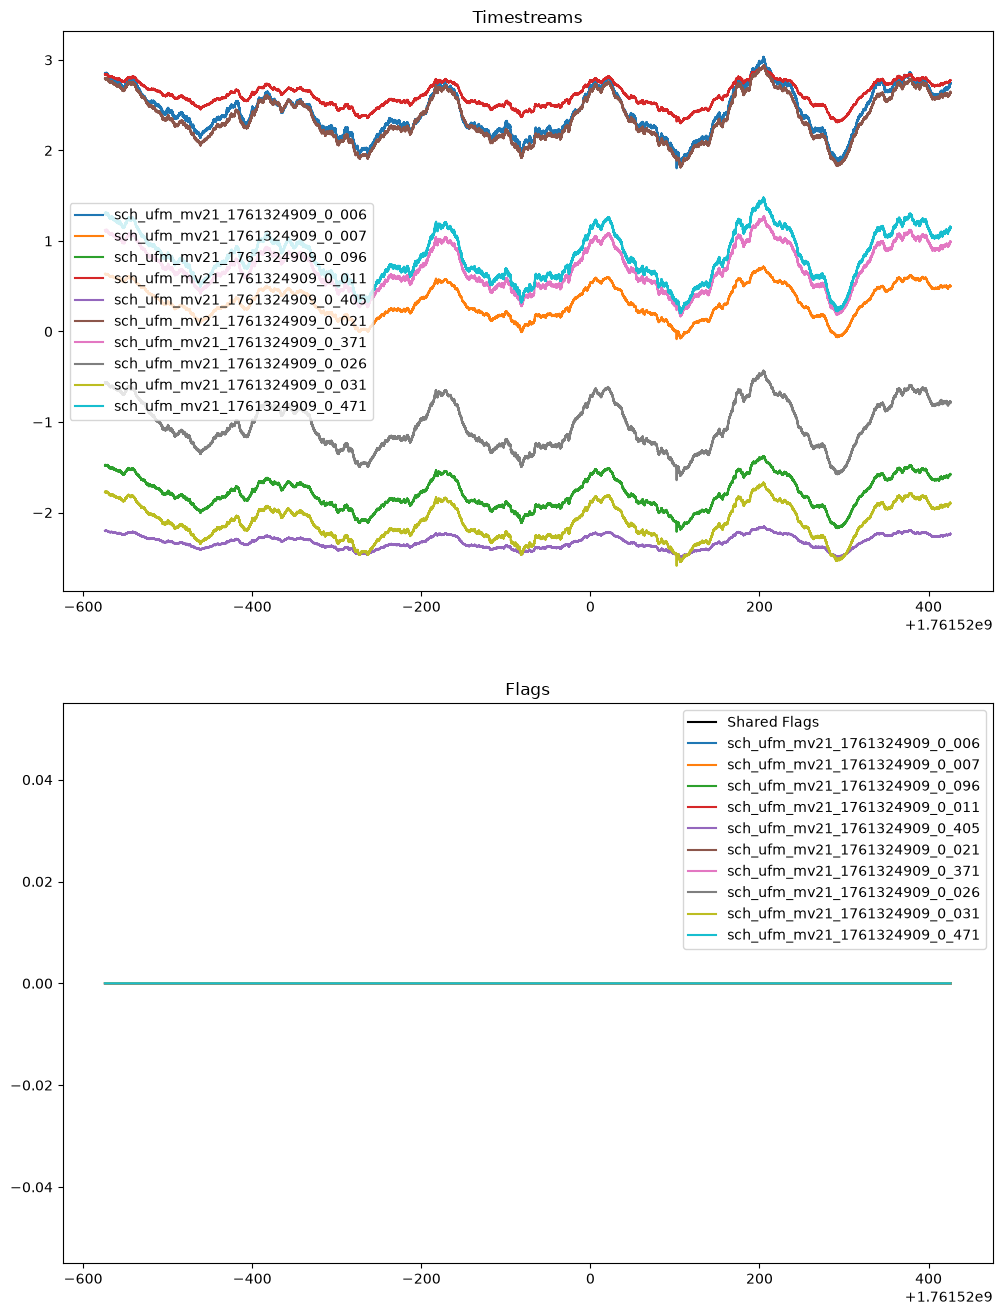

In [16]:
# Plot dets before processing
if rank == 0:
    plot_obs_dets(first_ob, d_start=0, d_end=10, s_end=200000)

# Low-level Preprocessing

We can now run basic pre-processing steps that we specified in our config files.

Note: if running on a jupyter node (instead of a batch job) this might take a while.

In [17]:
job_ops.pre_proc.apply(data)

TOAST INFO: extend_invalid (ExtendFlags) starting...
TOAST INFO: extend_invalid (ExtendFlags) executed in 0.0 s
TOAST INFO: az_intervals (AzimuthIntervals) starting...
TOAST INFO: az_intervals (AzimuthIntervals) executed in 0.0 s
TOAST INFO: bias_cuts (DetBiasCuts) starting...
TOAST INFO: bias_cuts (DetBiasCuts) executed in 0.0 s
TOAST INFO: raw_jumps (SimpleJumpCorrect) starting...
TOAST INFO: raw_jumps (SimpleJumpCorrect) executed in 7.0 s
TOAST INFO: trend_cuts (DetTrendCuts) starting...


/shared_home/software/soconda_builds/soconda_20260813_0.2.5/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/shared_home/software/soconda_builds/soconda_20260813_0.2.5/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/shared_home/software/soconda_builds/soconda_20260813_0.2.5/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/shared_home/software/soconda_builds/soconda_20260813_0.2.5/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


TOAST INFO: trend_cuts (DetTrendCuts) executed in 16.6 s
TOAST INFO: raw_deglitch (SimpleDeglitch) starting...
TOAST INFO: Flagged 0 / 636 badly glitched detectors over 1 observations
TOAST INFO: raw_deglitch (SimpleDeglitch) executed in 15.5 s
TOAST INFO: cal_to_pw (CalibrateDetectors) starting...
TOAST INFO: cal_to_pw (CalibrateDetectors) executed in 0.1 s
TOAST INFO: readout_filter (ReadoutFilter) starting...
TOAST INFO: readout_filter (ReadoutFilter) executed in 34.4 s
TOAST INFO: deconvolve_timeconstant (TimeConstant) starting...
TOAST INFO: deconvolve_timeconstant (TimeConstant) executed in 35.2 s


[None, None, None, None, None, None, None, None, None]

In [18]:
job_ops.noise_cut.apply(data)

TOAST INFO: diff_noise (SignalDiffNoiseModel) starting...
TOAST INFO: diff_noise (SignalDiffNoiseModel) executed in 0.9 s
TOAST INFO: diff_noise_cut (FlagNoiseFit) starting...
TOAST INFO: obs obs_1761519423_lati1_111_ufm_mv21|ALL|: flagged 5 noise model outlier detectors
TOAST INFO: Flagged 5 / 695 noise outliers over 1 observations
TOAST INFO: diff_noise_cut (FlagNoiseFit) executed in 0.7 s


[None, None]

In [19]:
# Remove a DC level in each detector for plotting
for det in first_ob.local_detectors:
    good = (first_ob.detdata["flags"][det] & defaults.det_mask_nonscience) == 0
    dc = np.mean(first_ob.detdata["signal"][det][good])
    first_ob.detdata["signal"][det] -= dc

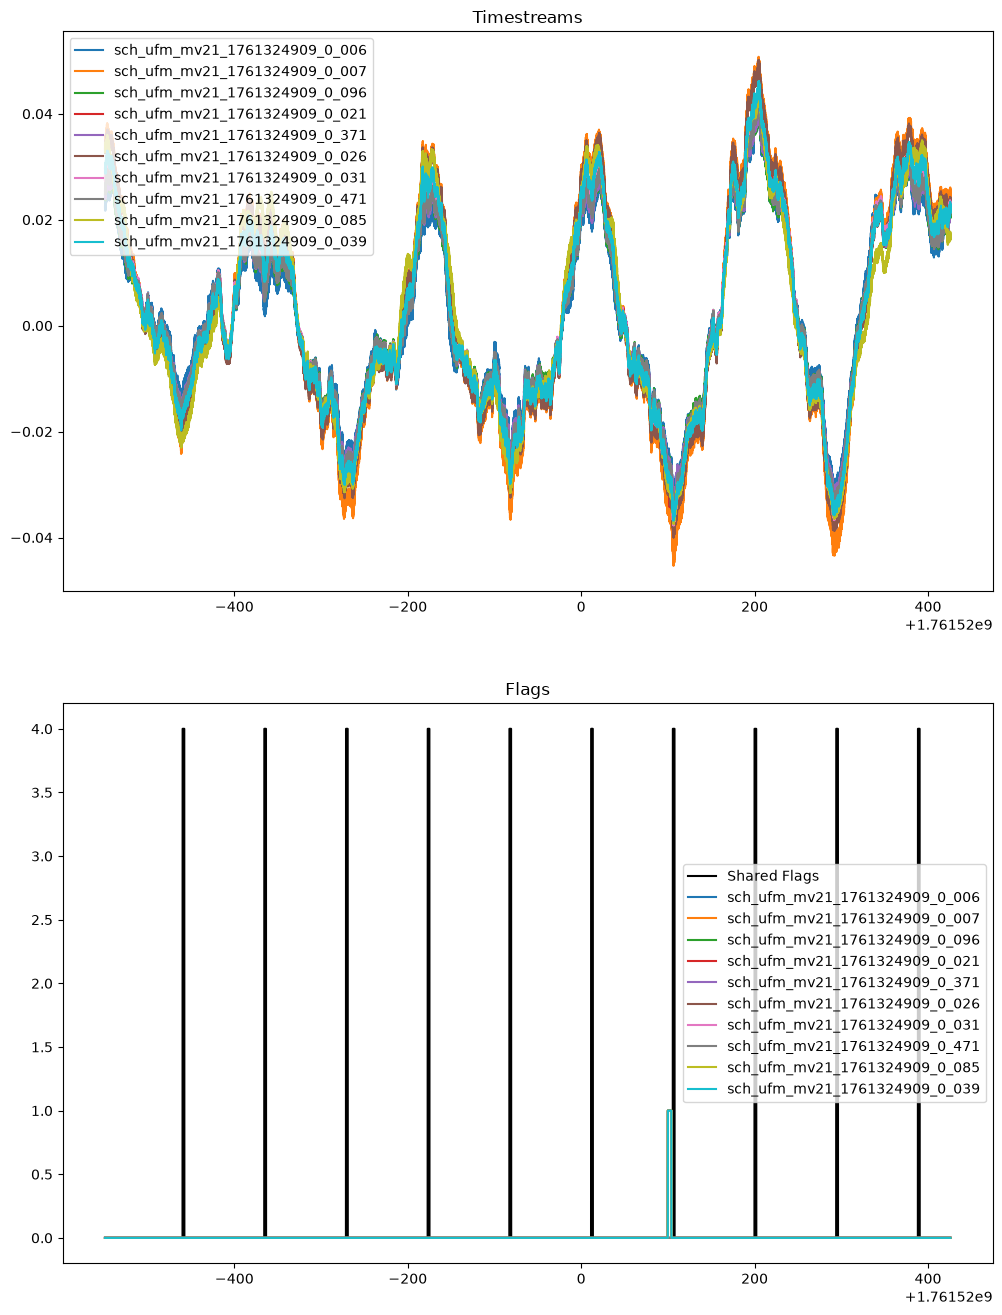

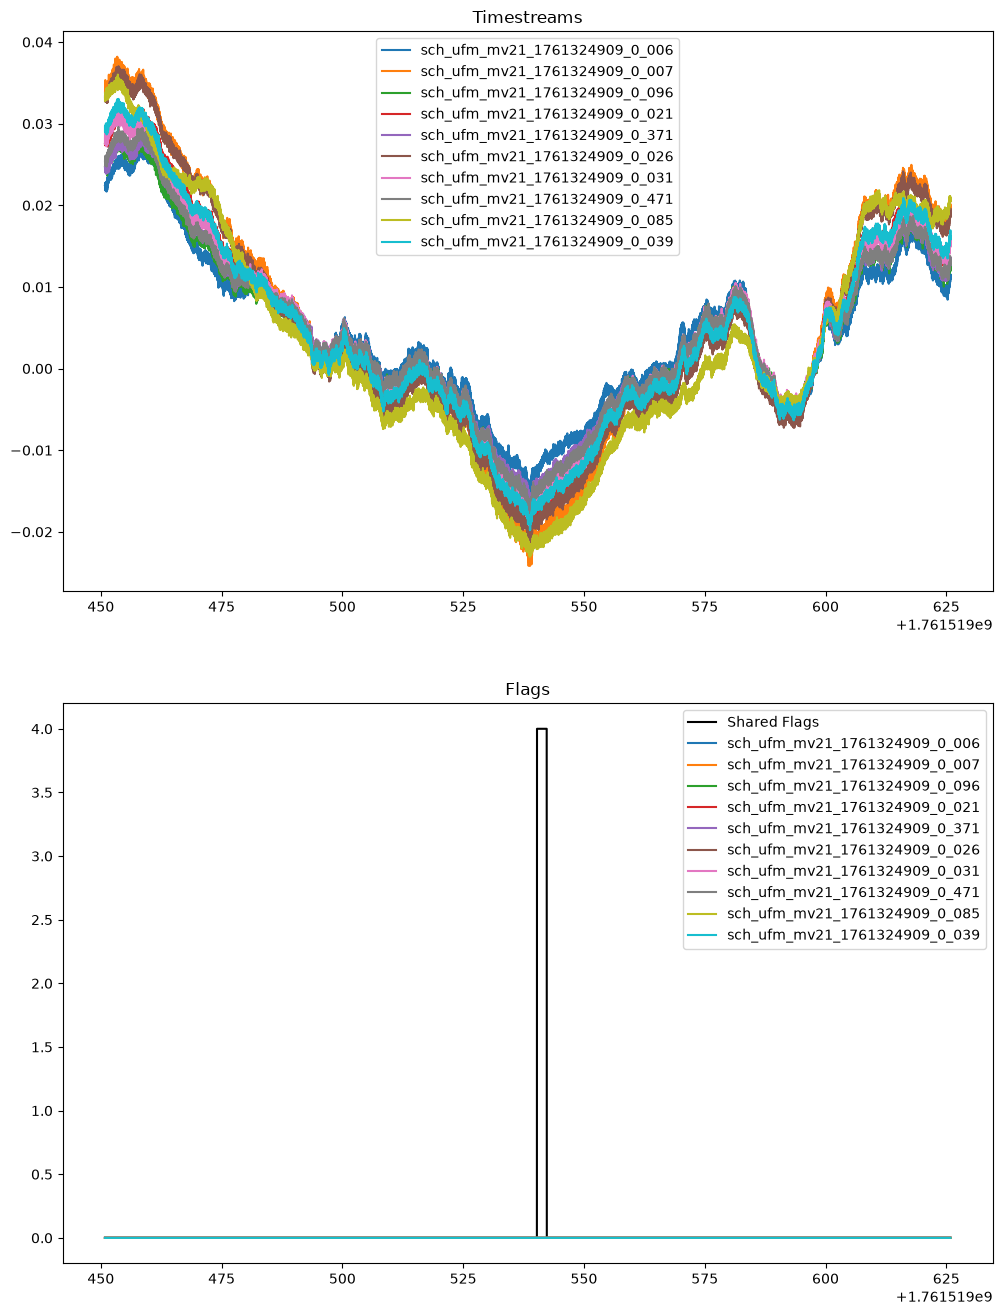

In [20]:
if rank == 0:
    plot_obs_dets(first_ob, d_start=0, d_end=10, s_start=5000, s_end=200000)
    plot_obs_dets(first_ob, d_start=0, d_end=10, s_start=5000, s_end=40000)

# Simulation

In [21]:
job_ops.simulate.apply(data)

TOAST INFO: sim_noise (SimNoise) starting...
TOAST INFO: sim_noise (SimNoise) executed in 33.5 s
TOAST INFO: sim_atmosphere (SimAtmosphere) starting...
TOAST INFO: sim_atmosphere (SimAtmosphere) executed in 78.6 s
TOAST INFO: sim_atmosphere_coarse (SimAtmosphere) starting...
TOAST INFO: sim_atmosphere_coarse (SimAtmosphere) executed in 65.0 s


[None, None, None, None, None, None]

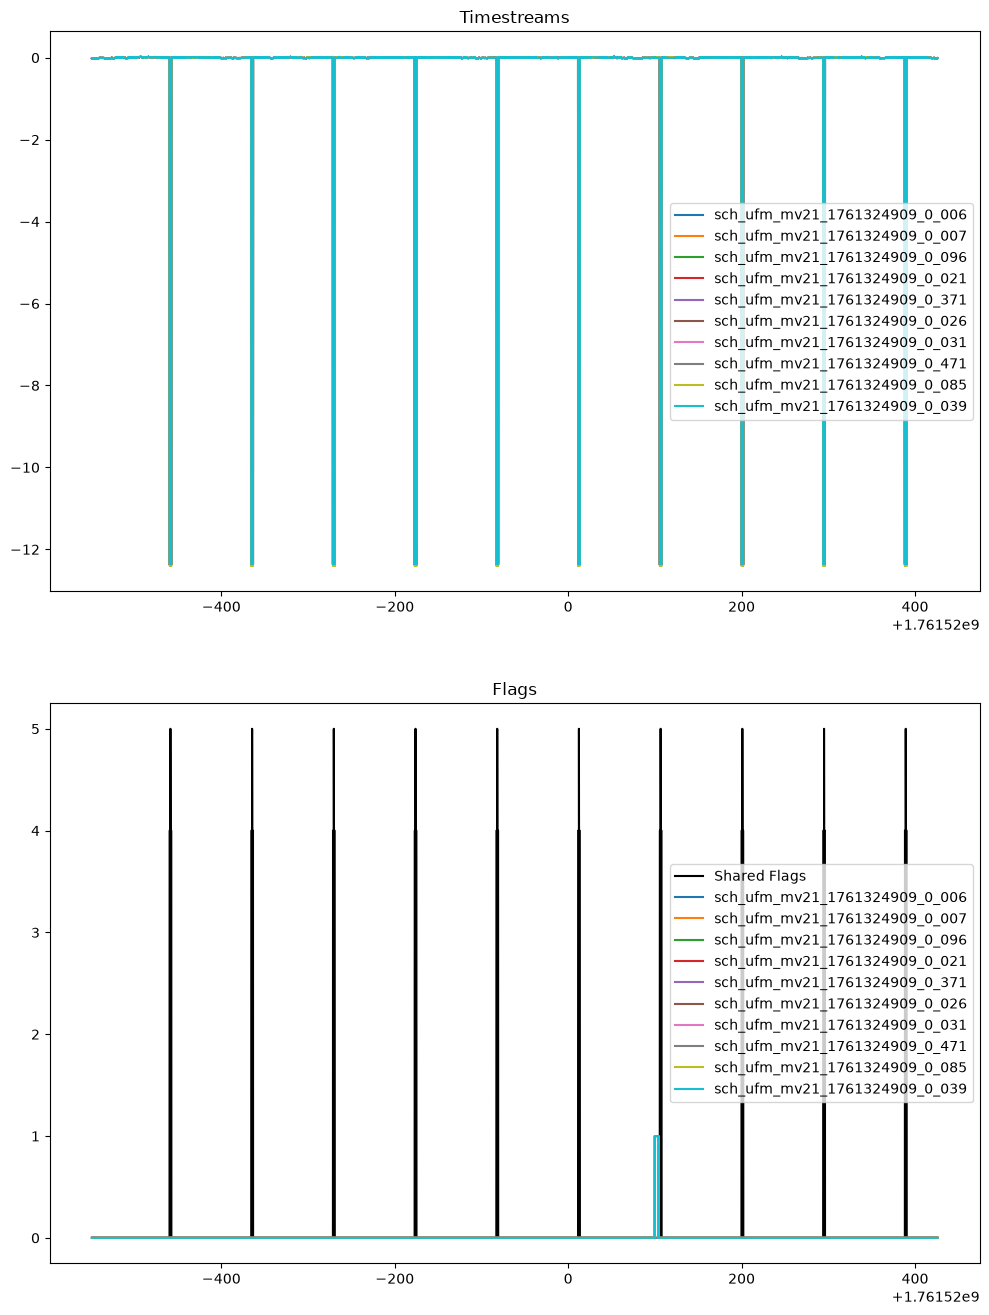

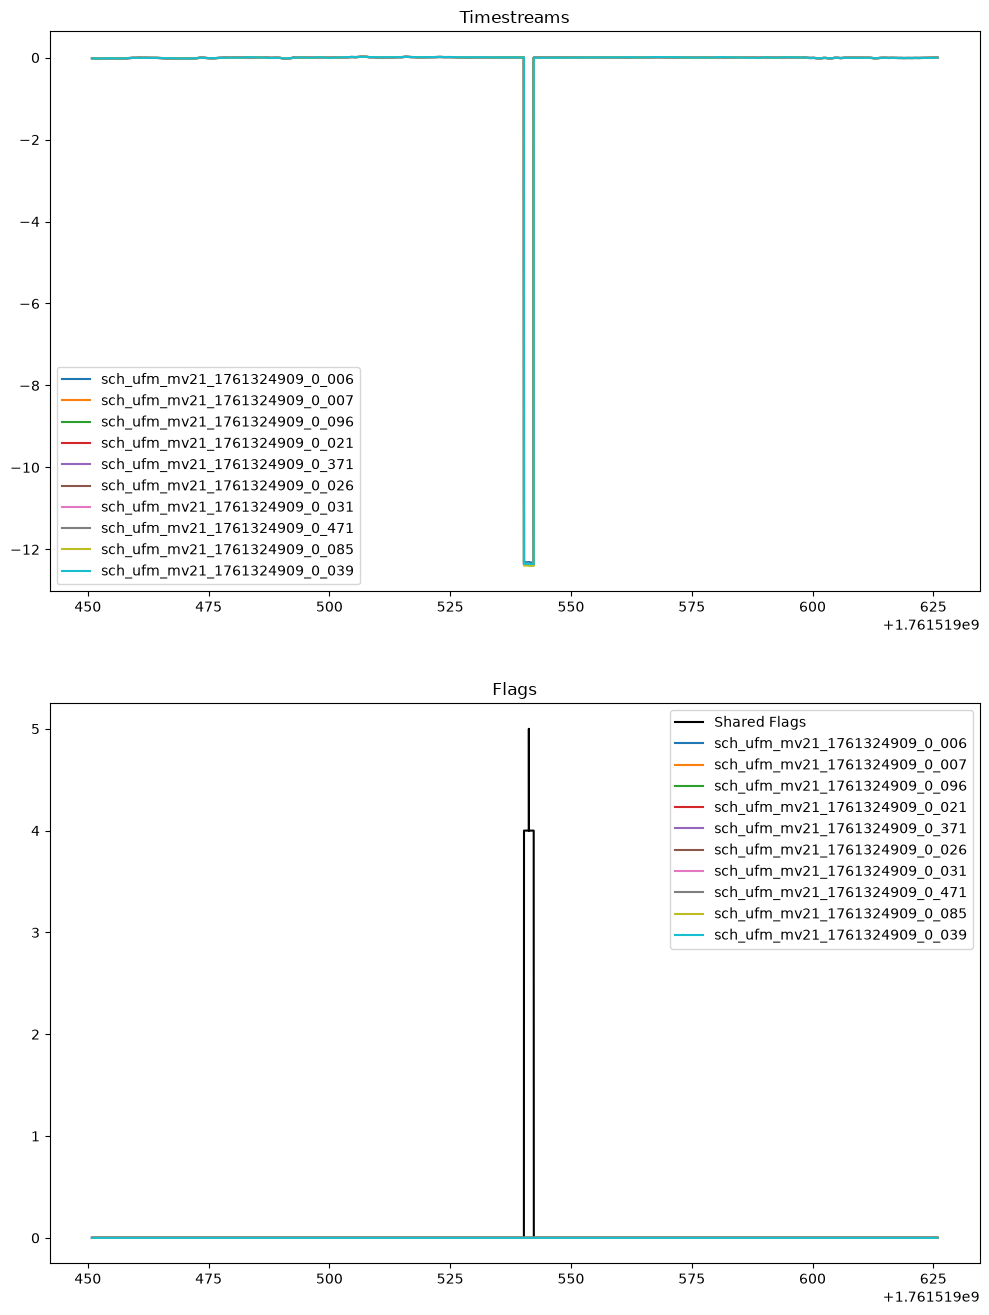

In [22]:
if rank == 0:
    plot_obs_dets(first_ob, d_start=0, d_end=10, s_start=5000, s_end=200000)
    plot_obs_dets(first_ob, d_start=0, d_end=10, s_start=5000, s_end=40000)

# Mapmaking

We define specifics about what mapmaking framework to use, as well as individual options within the mapmaker config file.

In this case we are using the `sotodlib.toast.ops.mlmapmaker.MLMapmaker` framework.

In [23]:
# We can print the settings we defined for the mapmaker here.
print(job_ops.mapmaker.__dict__)

{'_trait_values': {'API': 0, 'Nmat': None, 'area': 'so_geometry_v20241015_2p0.fits', 'boresight': 'boresight_azel', 'center_at': None, 'checkpoint_interval': 0, 'comps': 'TQU', 'deslope': True, 'det_data': 'signal', 'det_flag_mask': 1, 'det_flags': None, 'dtype_map': 'float64', 'enabled': True, 'interpol': 'nearest', 'name': 'mapmaker', 'nmat_dir': './nmat', 'nmat_mode': 'build', 'nmat_type': 'NmatDetvecs', 'noise_model': 'noise_model', 'out_dir': '.', 'purge_det_data': False, 'shared_flag_mask': 1, 'shared_flags': None, 'site': 'so', 'skip_existing': True, 'srcsamp': None, 'tiled': True, 'times': 'times', 'timing': False, 'timing_total': False, 'truncate_tod': True, 'verbose': 1, 'view': None, 'weather': 'toco', 'write_bin': True, 'write_div': 'all', 'write_hits': True, 'write_iter_map': 0, 'write_rhs': True, 'downsample': [10, 1], 'downweight': [], 'kernel_implementation': <ImplementationType.DEFAULT: 0>, 'maxerr': 1e-08, 'maxiter': [30, 20]}, '_trait_notifiers': {}, '_trait_validato

In [24]:
# Cleanup any stale files
for old in glob.glob("mapmaker_pass*"):
    os.remove(old)

In [25]:
job_ops.mapmaker.apply(data)

TOAST INFO: Starting pass 1/2, maxit=30 down=10, interp=nearest


RuntimeError: FAILED to build a noise model for observation='obs_1761519423_lati1_111_ufm_mv21' : 'Matrix is not positive definite'

# Results

In [ ]:
if rank == 0:
    from IPython.display import display, Image
    # hit_root = os.path.join(out_dir, "mapmaker_pass2_sky_hits")
    # map_root = os.path.join(out_dir, "mapmaker_pass2_sky_map")
    hit_root = "mapmaker_pass2_sky_hits"
    map_root = "mapmaker_pass2_sky_map"
    hit_file = f"{hit_root}.fits"
    map_file = f"{map_root}.fits"
    
    toast.vis.plot_wcs_maps(
        #hitfile=hit_file,
        mapfile=map_file,
        format="png",
        cmap="bwr",
        range_I=(-0.0001,0.0001),
        range_Q=(-0.0001,0.0001),
        range_U=(-0.0001,0.0001),
    )
    
    # hit_png = f"{hit_root}.png"
    # display(Image(hit_png))
    map_I_png = f"{map_root}_I.png"
    display(Image(map_I_png))
    map_Q_png = f"{map_root}_Q.png"
    display(Image(map_Q_png))
    map_U_png = f"{map_root}_U.png"
    display(Image(map_U_png))